In [34]:
#knn calssification 

#its lazy learner 



In [35]:
#imports

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report ,accuracy_score 



In [36]:
#load dataset
data = load_breast_cancer()

df =pd.DataFrame(data= data.data,
                columns= data.feature_names)

df["target"] = data.target

print(df.head(5))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [37]:
#data understanding 
df.info
df.shape
df.columns
df.describe()
df.isnull().mean()
df.duplicated().mean()

df['target'].value_counts()



target
1    357
0    212
Name: count, dtype: int64

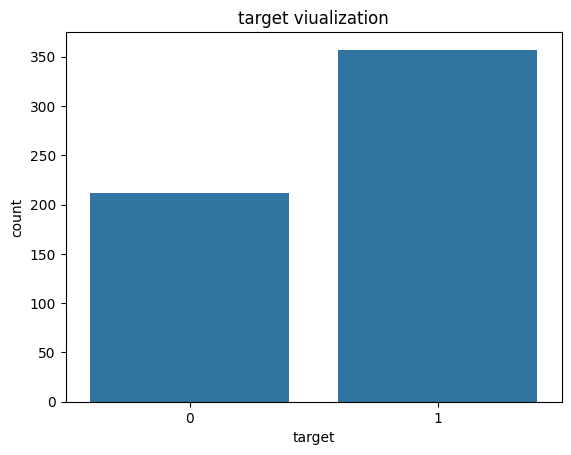

In [38]:
#visualization

sns.countplot(data=df , x="target")
plt.title("target viualization")
plt.show()

In [39]:
# there is no missing value so we dont need to use simpleimputer
# 
# Feature & Target Separation


X = df.drop("target",axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X,y ,test_size= 0.2 , random_state= 42 , stratify=y)
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [40]:
#preporccessing pipeline 

pipeline = Pipeline([
    ("scaler" , StandardScaler()),
    ("model" , KNeighborsClassifier())

]) 

pipeline.fit(X_train ,y_train)

pred = pipeline.predict(X_test)

print(pred[0])

0


In [42]:
#metrics 

accuracy =  accuracy_score(pred ,y_test)
report =classification_report(pred , y_test)
print(report)

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        41
           1       0.97      0.96      0.97        73

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [46]:
import  joblib

joblib.dump(pipeline , "knn.psl")

['knn.psl']